Inspirations / Learning tools:
[ Sentiment Analysis with BERT Neural Network and Python ](https://www.youtube.com/watch?v=szczpgOEdXs&t=1083s)

# Import data, create model

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency

In [2]:
# Choose model

model_id = "finiteautomata/bertweet-base-sentiment-analysis"


In [3]:
# Create model
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForSequenceClassification.from_pretrained(model_id)

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


In [4]:
df = pd.read_csv('data/reddit_posts.csv')
df.columns

Index(['Title', 'Political Lean', 'Score', 'Subreddit', 'Num of Comments',
       'Text', 'Date Created'],
      dtype='object')

In [5]:
df = df.rename(columns={"Title": "title", "Text": "selftext"})
df['Date Created'] = pd.to_datetime(df['Date Created'], unit='s')

# Define function for sentiment analysis:

In [6]:
def sentiment_analysis(model, post_str):
    tokens = tokenizer.encode(post_str, return_tensors="pt")
    result = model(tokens)
    if int(torch.argmax(result.logits)) < 0:
        print(post_str)
    return int(torch.argmax(result.logits)) + 1

In [7]:
def chisquare_analysis(data):
    stat, p, dof, expected = chi2_contingency(data)
    return p

In [ ]:
#create new column in df:
df["Sentiment"] = 0
for i in range(0, len(df)):

    df.at[i, "Sentiment"] = sentiment_analysis(model, df.iloc[i]["title"])

df.to_csv("data/reddit_posts_sentiment.csv", index=False)

In [ ]:
df = pd.read_csv("data/reddit_posts_sentiment.csv")

# Visualisations

After performing chi2 analysis, we find a p-value of 0.2519636669235628


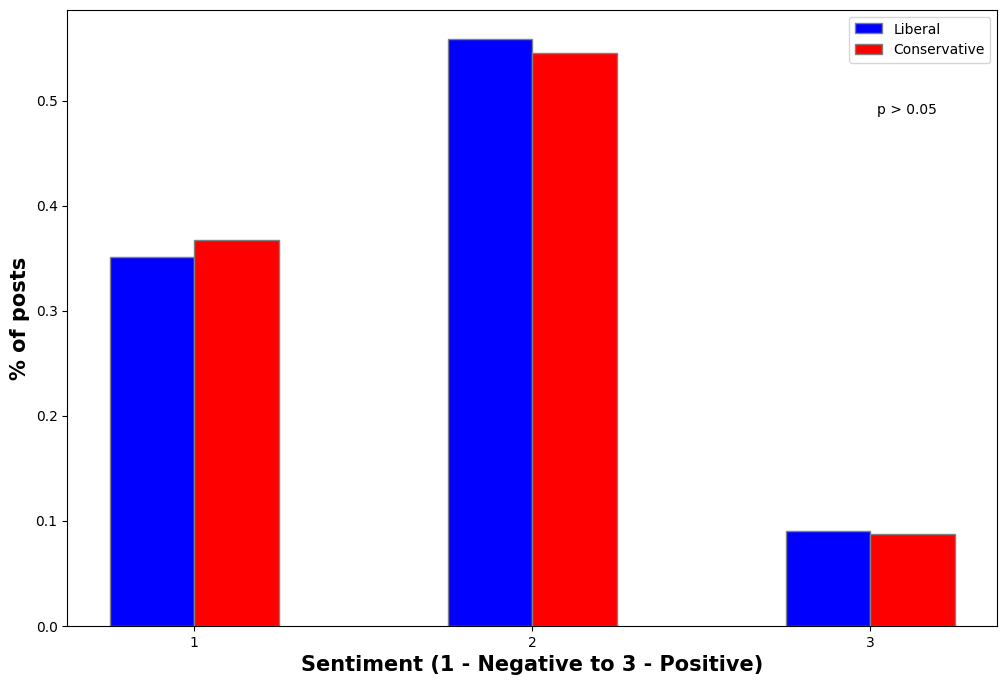

In [ ]:
# Dichotomy lib / cons


num_lib_posts = df.groupby("Political Lean").size()["Liberal"]
num_cons_posts = df.groupby("Political Lean").size()["Conservative"]
sentiments_lib_cat = df[df["Political Lean"] == "Liberal"].groupby(by="Sentiment").size().to_list() 
sentiments_cons_cat = df[df["Political Lean"] == "Conservative"].groupby(by="Sentiment").size().to_list() 

# Sentiment distribution in liberal/conservative
chi_square = chisquare_analysis([sentiments_lib_cat, sentiments_cons_cat])
print(f"After performing chi2 analysis, we find a p-value of {chi_square}")

sentiments_lib_cat = sentiments_lib_cat / num_lib_posts
sentiments_cons_cat = sentiments_cons_cat /num_cons_posts

barWidth = 0.25
fig = plt.subplots(figsize =(12, 8))

br1 = np.arange(len(sentiments_lib_cat)) 
br2 = [x + barWidth for x in br1] 

plt.bar(br1, sentiments_lib_cat, color ='b', width = barWidth, 
        edgecolor ='grey', label ='Liberal') 
plt.bar(br2, sentiments_cons_cat, color ='r', width = barWidth, 
        edgecolor ='grey', label ='Conservative')

plt.xlabel('Sentiment (1 - Negative to 3 - Positive)', fontweight ='bold', fontsize = 15) 
plt.ylabel('% of posts', fontweight ='bold', fontsize = 15) 
plt.xticks([r + barWidth /2 for r in range(len(sentiments_lib_cat))], 
        ['1', '2', '3'])

if chi_square < 0.05:
        plt.figtext(.8, .75, f"p < 0.05")
else:
        plt.figtext(.8, .75, f"p > 0.05")


plt.legend()
plt.show()  

After performing chi2 analysis, we find a p-value of 0.0


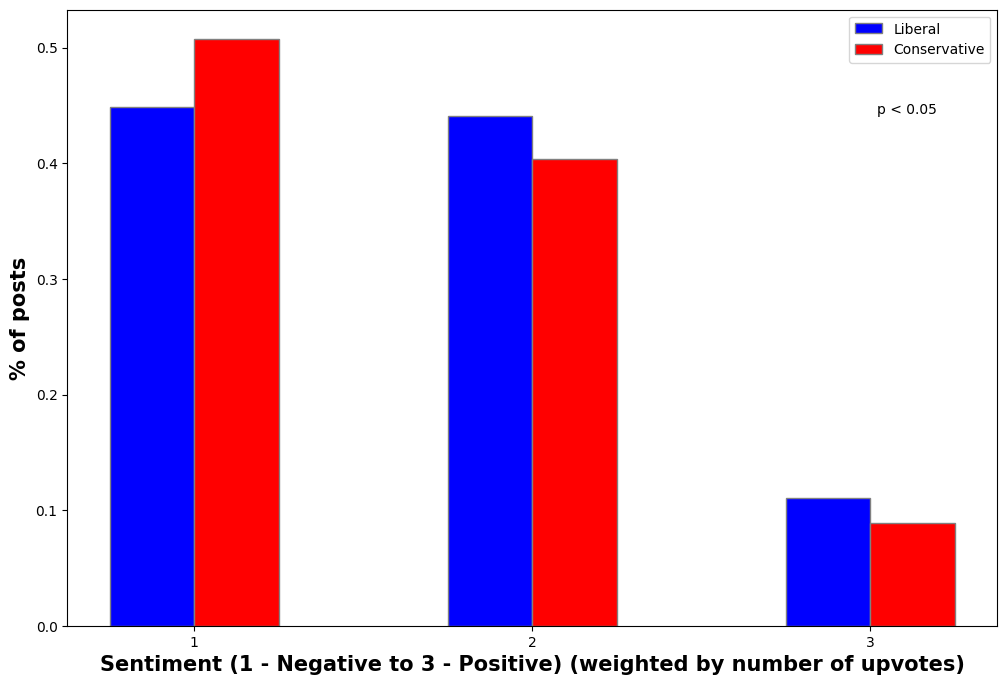

In [ ]:
sentiment_lib_weighted = [0,0,0]
sentiment_cons_weighted = [0,0,0]
for i in range(len(df)):
    post = df.iloc[i]
    if post["Political Lean"] == "Liberal":
        sentiment_lib_weighted[post["Sentiment"]-1] += post["Score"]
    if post["Political Lean"] == "Conservative":
        sentiment_cons_weighted[post["Sentiment"]-1] += post["Score"]

chi_square = chisquare_analysis([sentiment_lib_weighted, sentiment_cons_weighted])
print(f"After performing chi2 analysis, we find a p-value of {chi_square}")

sentiment_lib_weighted = sentiment_lib_weighted / sum(sentiment_lib_weighted)
sentiment_cons_weighted = sentiment_cons_weighted / sum(sentiment_cons_weighted)

barWidth = 0.25
fig = plt.subplots(figsize =(12, 8))

br1 = np.arange(len(sentiments_lib_cat)) 
br2 = [x + barWidth for x in br1] 

plt.bar(br1, sentiment_lib_weighted, color ='b', width = barWidth, 
        edgecolor ='grey', label ='Liberal') 
plt.bar(br2, sentiment_cons_weighted, color ='r', width = barWidth, 
        edgecolor ='grey', label ='Conservative')

plt.xlabel('Sentiment (1 - Negative to 3 - Positive) (weighted by number of upvotes)', fontweight ='bold', fontsize = 15) 
plt.ylabel('% of posts', fontweight ='bold', fontsize = 15) 
plt.xticks([r + barWidth/2 for r in range(len(sentiment_lib_weighted))], 
        ['1', '2', '3'])

if chi_square < 0.05:
        plt.figtext(.8, .75, f"p < 0.05")
else:
        plt.figtext(.8, .75, f"p > 0.05")

plt.legend()
plt.show()  

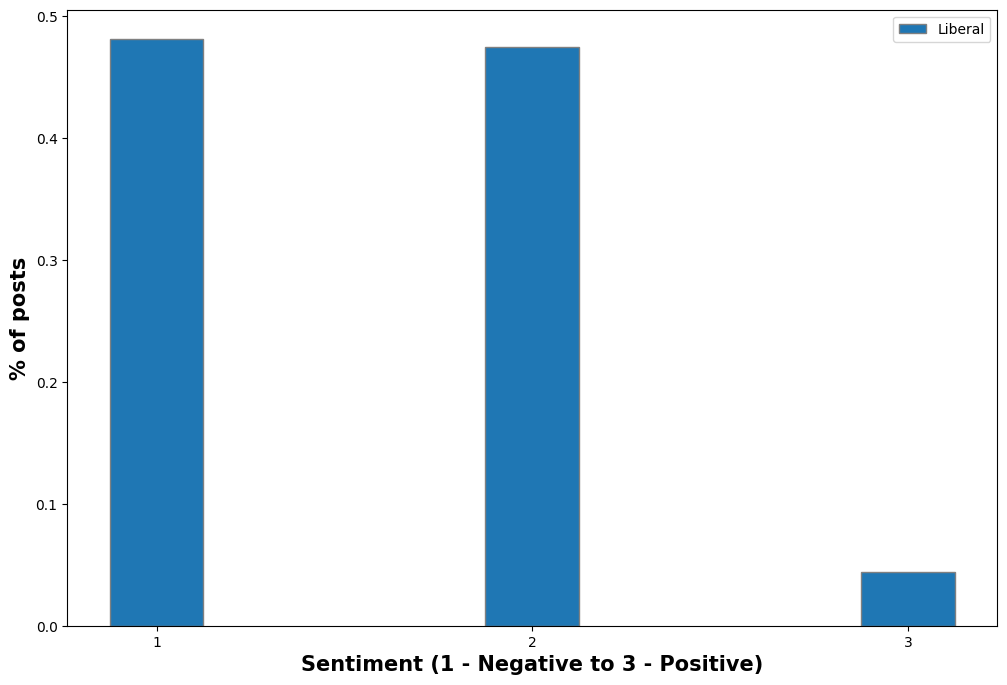

In [ ]:
subreddit = "Liberal"


num_posts = df.groupby("Subreddit").size()[subreddit]
sentiments_cat = df[df["Subreddit"] == subreddit].groupby(by="Sentiment").size().to_list() 


sentiments_cat = sentiments_cat / num_posts

barWidth = 0.25
fig = plt.subplots(figsize =(12, 8))

br1 = np.arange(len(sentiments_cat)) 

plt.bar(br1, sentiments_cat, width = barWidth, 
        edgecolor ='grey', label =subreddit) 

plt.xlabel('Sentiment (1 - Negative to 3 - Positive)', fontweight ='bold', fontsize = 15) 
plt.ylabel('% of posts', fontweight ='bold', fontsize = 15) 
plt.xticks([r  for r in range(len(sentiments_cat))], 
        ['1', '2', '3'])

plt.legend()
plt.show()  

# Sentiments per topic

In [ ]:
df = pd.read_csv("data/reddit_posts_sentiment.csv")

In [ ]:
df_topics = pd.read_csv("data/most_common_topic.csv")
df_sentiment_topics = pd.concat([df_topics, df["Sentiment"].rename("Sentiment")], axis=1)

In [ ]:
df_sentiment_topics.columns

Index(['title', 'Political Lean', 'Score', 'Subreddit', 'Num of Comments',
       'selftext', 'Date Created', 'title_clean', 'selftext_clean',
       'norm_score', 'most_common_topic', 'Sentiment'],
      dtype='object')

In [ ]:
def analyse_topics(topic_number, normalize=False, score_weight=False):
        df_topics = df_sentiment_topics[df_sentiment_topics["most_common_topic"] == topic_number]

        subreddit_distrib = {}

        sentiment_lib = [0,0,0]
        sentiment_cons = [0,0,0]
        for i in range(len(df_topics)):
                post = df_topics.iloc[i]
                if post["Political Lean"] == "Liberal":
                        if score_weight:
                                sentiment_lib[post["Sentiment"]-1] += post["Score"] 
                        else:
                                sentiment_lib[post["Sentiment"]-1] += 1
                if post["Political Lean"] == "Conservative":
                        if score_weight:
                                sentiment_cons[post["Sentiment"]-1] += post["Score"] 
                        else:
                                sentiment_cons[post["Sentiment"]-1] += 1
                try:
                        subreddit_distrib[post["Subreddit"]][post["Sentiment"] - 1] += 1
                except:
                        subreddit_distrib[post["Subreddit"]] = [0,0,0]
                        subreddit_distrib[post["Subreddit"]][post["Sentiment"] - 1] +=1

        print(f"=== Topic {topic_number} ===")
        print(subreddit_distrib)
        try:
                chi_square = chisquare_analysis([sentiment_lib, sentiment_cons])
                print(f"After performing chi2 analysis, we find a p-value of {chi_square}")
        except:
                chi_square = None

        if normalize:
                total_lib = sentiment_lib.copy()
                sentiment_lib = np.array(sentiment_lib) / sum(sentiment_lib)
                total_cons = sentiment_cons.copy()
                sentiment_cons = np.array(sentiment_cons) / sum(sentiment_cons)



        barWidth = 0.25
        plt.subplots(figsize =(12, 8))

        br1 = np.arange(len(sentiment_lib)) 
        br2 = [x + barWidth for x in br1] 

        plt.bar(br1, sentiment_lib, color ='b', width = barWidth, 
                edgecolor ='grey', label ='Liberal') 
        plt.bar(br2, sentiment_cons, color ='r', width = barWidth, 
                edgecolor ='grey', label ='Conservative')
        
        for i in range(len(br1)):
                plt.text(i, sentiment_lib[i], total_lib[i], ha='center')
        for i in range(len(br2)):
                plt.text(i + barWidth, sentiment_cons[i], total_cons[i], ha='center')

        plt.xlabel(f'Sentiment of topic {topic_number} (1 - Negative to 3 - Positive)', fontweight ='bold', fontsize = 15) 

        if normalize:
                plt.ylabel('% of posts', fontweight ='bold', fontsize = 15) 
        else:
                plt.ylabel('Number of posts', fontweight ='bold', fontsize = 15) 
        plt.xticks([r + barWidth /2 for r in range(len(sentiment_lib))], 
                ['1', '2', '3'])

        if chi_square == None:
                plt.figtext(.8, .75, "Chi-square not pertinent")
        elif chi_square < 0.05:
                plt.figtext(.8, .75, f"p < 0.05")
        else:
                plt.figtext(.8, .75, f"p > 0.05")

        plt.legend()
        plt.savefig(f"plots/sentiment_topic_{topic_number}")
        plt.show()

=== Topic 0 ===
{'socialism': [47, 211, 24], 'democrats': [9, 13, 9], 'SocialDemocracy': [47, 296, 41], 'DemocraticSocialism': [67, 138, 19], 'alltheleft': [66, 121, 29], 'feminisms': [6, 14, 2], 'Liberal': [7, 12, 2], 'progressive': [18, 36, 6], 'Communist': [33, 126, 26], 'Capitalism': [128, 245, 61], 'Libertarian': [33, 87, 13], 'republicans': [9, 12, 7], 'conservatives': [7, 20, 11], 'anarchocapitalism': [55, 175, 17]}
After performing chi2 analysis, we find a p-value of 0.003929402614848492


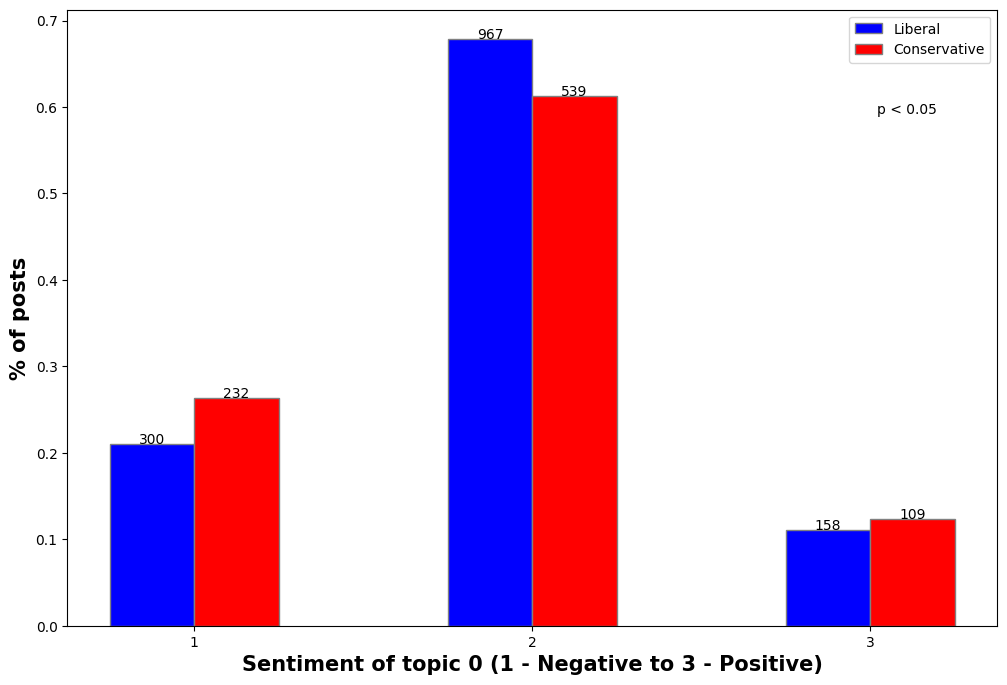

=== Topic 1 ===
{'democrats': [60, 91, 29], 'DemocraticSocialism': [17, 20, 6], 'progressive': [43, 42, 11], 'socialism': [3, 6, 0], 'Liberal': [63, 60, 5], 'alltheleft': [18, 10, 1], 'Communist': [1, 3, 1], 'SocialDemocracy': [6, 10, 3], 'feminisms': [3, 8, 1], 'conservatives': [82, 70, 10], 'republicans': [75, 82, 13], 'Libertarian': [13, 22, 0], 'Capitalism': [5, 4, 0], 'anarchocapitalism': [3, 5, 2]}
After performing chi2 analysis, we find a p-value of 0.04493940501905737


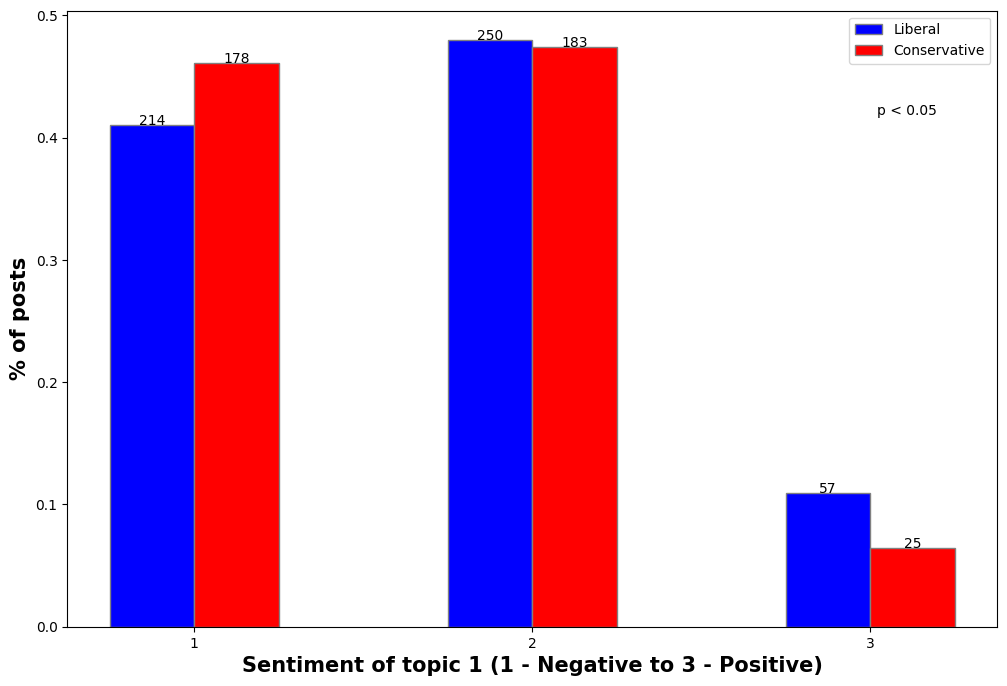

=== Topic 2 ===
{'democrats': [17, 24, 2], 'alltheleft': [31, 38, 4], 'SocialDemocracy': [7, 32, 2], 'Liberal': [14, 13, 0], 'progressive': [5, 8, 1], 'DemocraticSocialism': [10, 27, 2], 'feminisms': [3, 0, 1], 'socialism': [18, 42, 0], 'Communist': [1, 11, 1], 'Libertarian': [89, 93, 9], 'conservatives': [89, 106, 7], 'republicans': [38, 34, 3], 'Capitalism': [11, 13, 3], 'anarchocapitalism': [3, 5, 0]}
After performing chi2 analysis, we find a p-value of 0.0024428576852474314


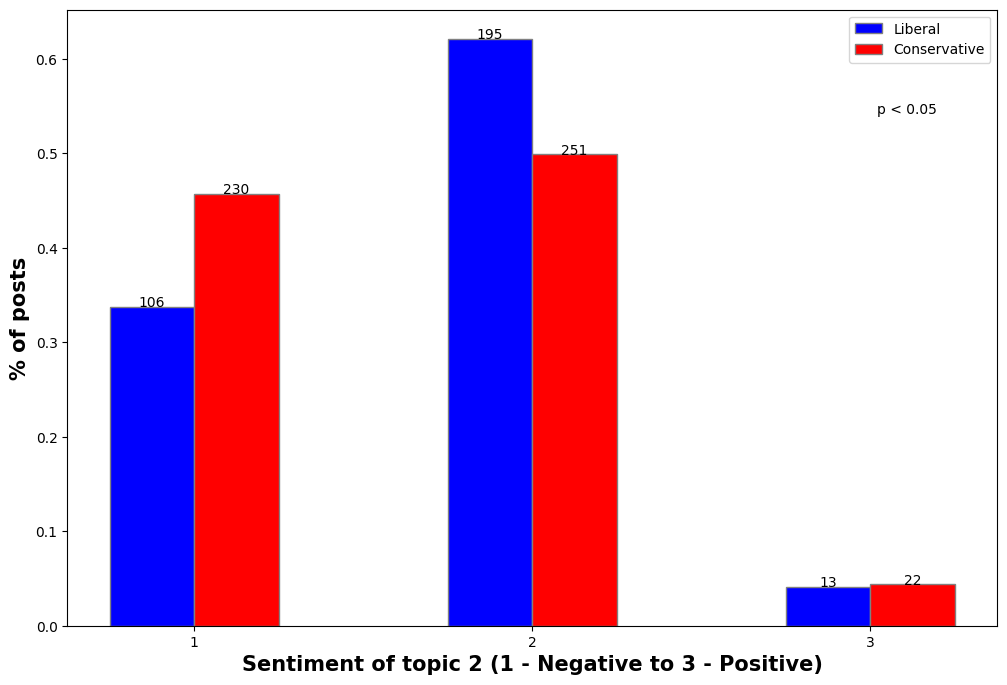

=== Topic 3 ===
{'progressive': [81, 105, 9], 'Liberal': [92, 87, 7], 'democrats': [76, 106, 23], 'SocialDemocracy': [10, 35, 5], 'alltheleft': [43, 29, 8], 'DemocraticSocialism': [45, 62, 13], 'socialism': [17, 8, 0], 'feminisms': [8, 2, 0], 'Communist': [10, 12, 0], 'conservatives': [39, 39, 8], 'republicans': [52, 56, 10], 'Libertarian': [29, 27, 1], 'Capitalism': [15, 10, 2], 'anarchocapitalism': [18, 16, 1]}
After performing chi2 analysis, we find a p-value of 0.3615528383465526


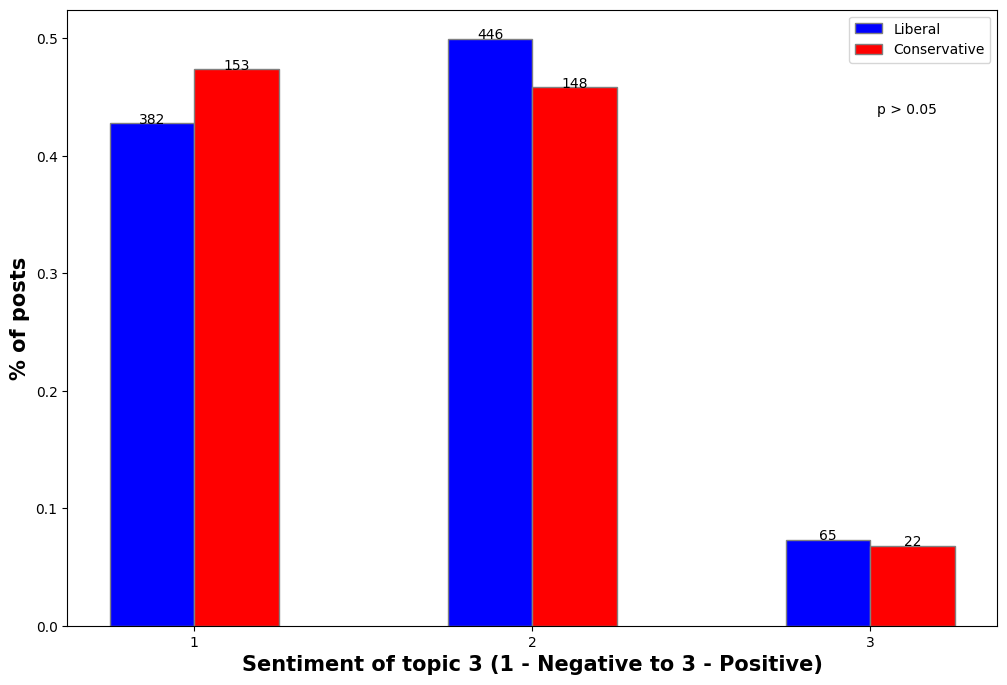

=== Topic 4 ===
{'democrats': [5, 7, 4], 'alltheleft': [18, 42, 17], 'socialism': [2, 7, 7], 'SocialDemocracy': [1, 27, 5], 'DemocraticSocialism': [12, 33, 10], 'Liberal': [0, 1, 2], 'feminisms': [0, 1, 1], 'progressive': [1, 0, 0], 'Communist': [1, 2, 0], 'republicans': [8, 25, 14], 'conservatives': [4, 25, 9], 'Libertarian': [2, 6, 4], 'Capitalism': [2, 12, 6], 'anarchocapitalism': [0, 7, 2]}
After performing chi2 analysis, we find a p-value of 0.21599348295260792


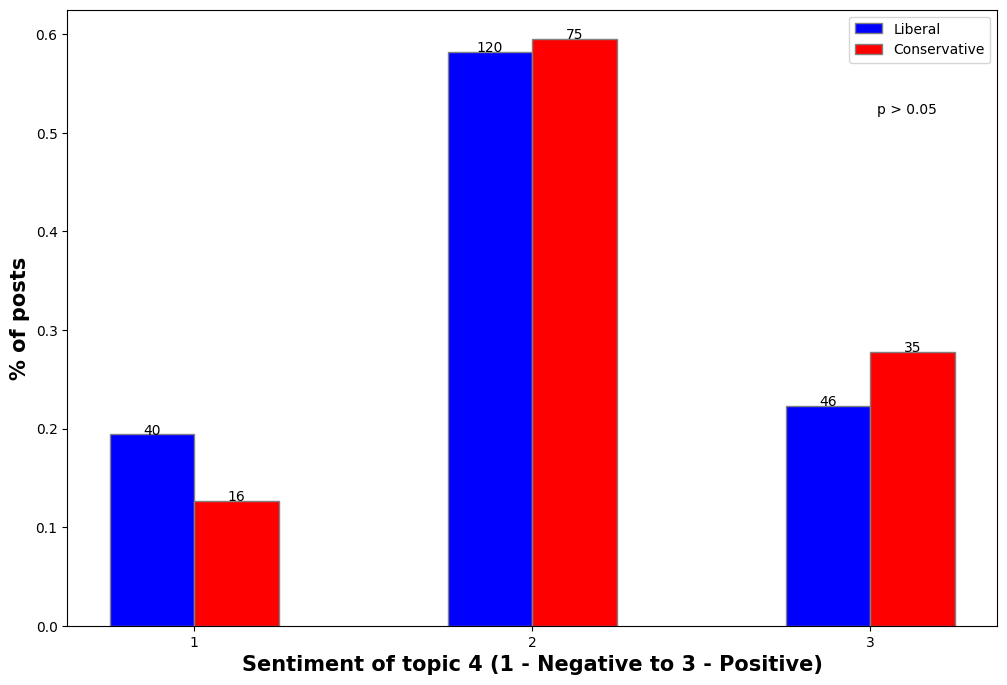

=== Topic 5 ===
{'democrats': [3, 7, 0], 'socialism': [13, 9, 0], 'SocialDemocracy': [5, 6, 0], 'alltheleft': [16, 10, 0], 'progressive': [30, 21, 4], 'Liberal': [20, 14, 0], 'DemocraticSocialism': [10, 8, 1], 'feminisms': [9, 3, 0], 'Communist': [3, 0, 0], 'conservatives': [3, 6, 0], 'Libertarian': [14, 43, 2], 'anarchocapitalism': [11, 9, 0], 'republicans': [1, 3, 0], 'Capitalism': [9, 14, 2]}
After performing chi2 analysis, we find a p-value of 0.00017720938436536365


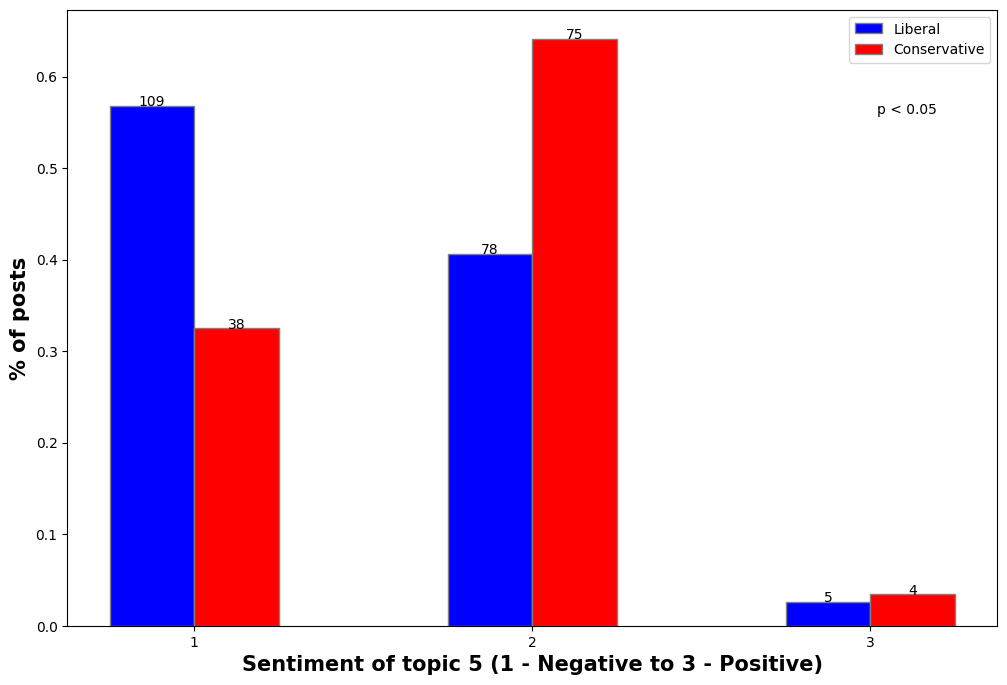

=== Topic 6 ===
{'socialism': [7, 11, 0], 'democrats': [13, 6, 3], 'Liberal': [14, 14, 3], 'alltheleft': [13, 8, 1], 'progressive': [25, 18, 1], 'SocialDemocracy': [2, 5, 1], 'DemocraticSocialism': [4, 3, 2], 'feminisms': [3, 2, 0], 'Communist': [4, 4, 0], 'republicans': [21, 15, 1], 'conservatives': [18, 16, 5], 'Libertarian': [43, 35, 3], 'Capitalism': [1, 1, 0], 'anarchocapitalism': [8, 8, 0]}
After performing chi2 analysis, we find a p-value of 0.8490904945624212


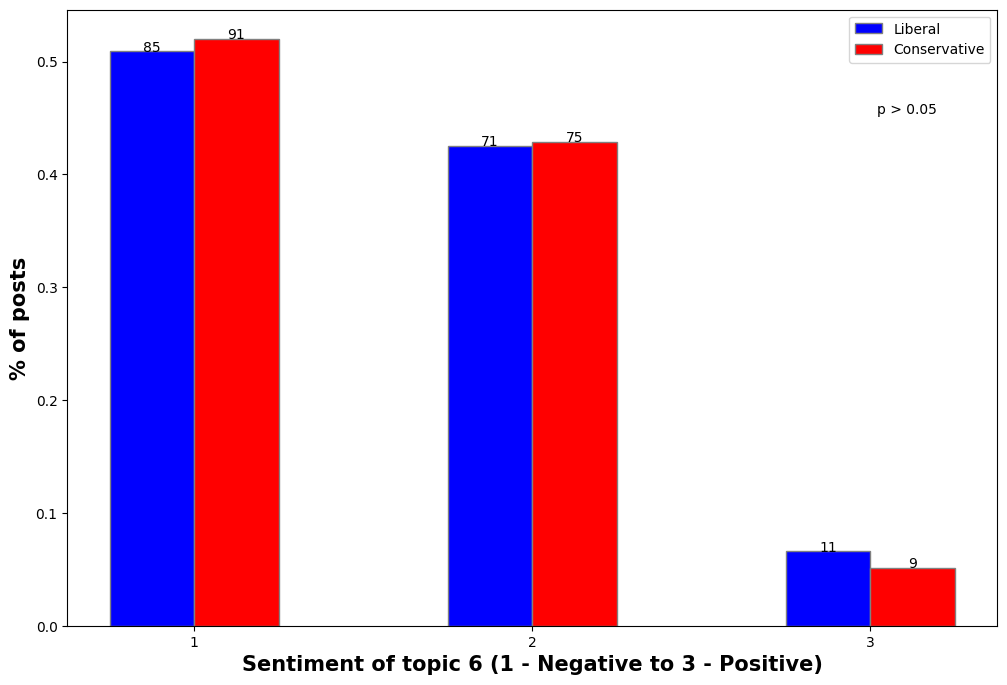

=== Topic 7 ===
{'democrats': [32, 32, 1], 'Liberal': [63, 74, 0], 'alltheleft': [1, 3, 0], 'progressive': [26, 41, 1], 'DemocraticSocialism': [1, 4, 2], 'SocialDemocracy': [0, 1, 0], 'feminisms': [5, 1, 0], 'Communist': [2, 3, 0], 'conservatives': [25, 35, 2], 'Libertarian': [7, 6, 0], 'republicans': [38, 71, 3], 'Capitalism': [0, 3, 0], 'anarchocapitalism': [1, 1, 1]}
After performing chi2 analysis, we find a p-value of 0.1328663892808553


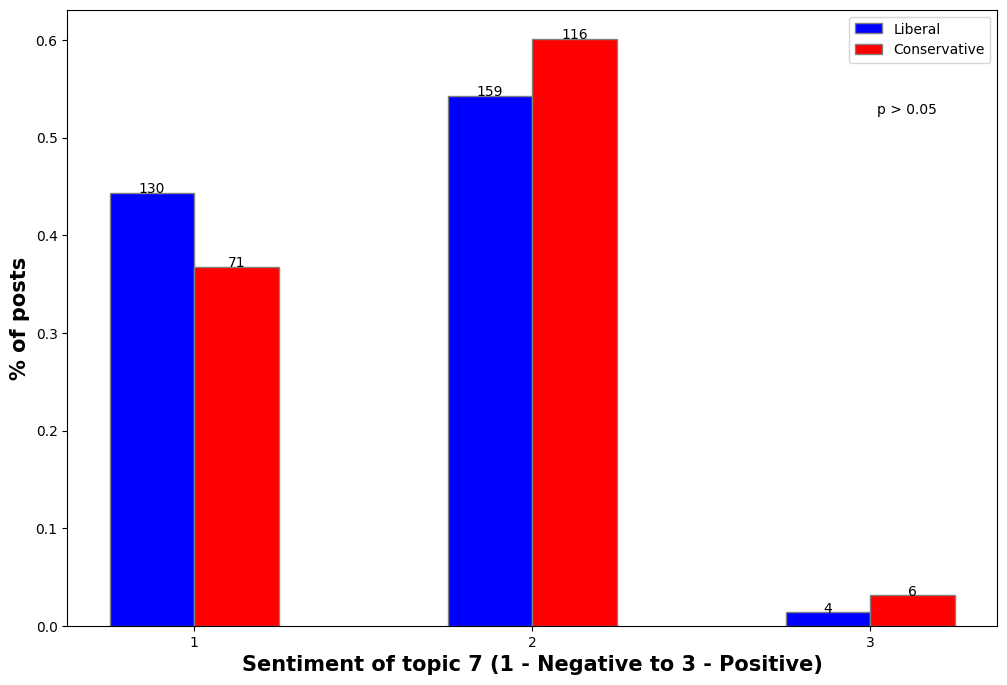

=== Topic 8 ===
{'socialism': [3, 11, 0], 'democrats': [9, 17, 4], 'alltheleft': [7, 12, 0], 'DemocraticSocialism': [10, 12, 3], 'SocialDemocracy': [4, 13, 2], 'Communist': [1, 4, 0], 'Liberal': [30, 15, 2], 'progressive': [18, 11, 3], 'feminisms': [1, 3, 1], 'conservatives': [18, 19, 5], 'republicans': [11, 8, 0], 'Libertarian': [11, 20, 2], 'Capitalism': [4, 5, 0], 'anarchocapitalism': [1, 6, 1]}
After performing chi2 analysis, we find a p-value of 0.93006142181493


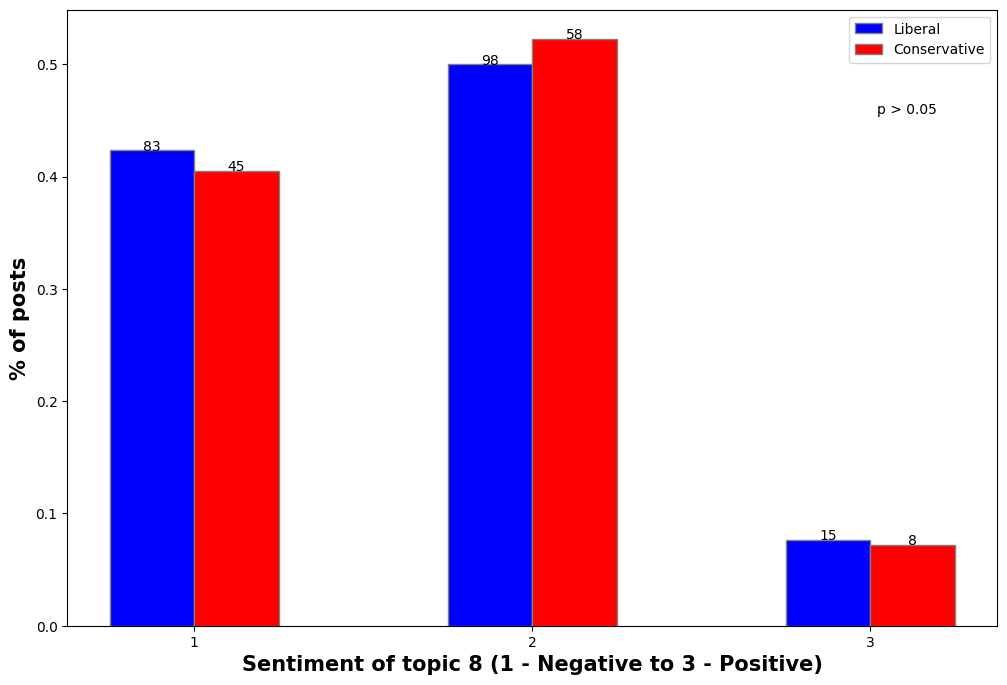

=== Topic 9 ===
{'socialism': [6, 10, 0], 'SocialDemocracy': [8, 23, 2], 'democrats': [0, 7, 1], 'progressive': [9, 16, 2], 'alltheleft': [4, 4, 2], 'DemocraticSocialism': [10, 6, 3], 'Liberal': [6, 2, 2], 'Libertarian': [10, 4, 2], 'republicans': [6, 5, 1], 'conservatives': [5, 1, 1], 'Capitalism': [25, 23, 3], 'anarchocapitalism': [1, 5, 1]}
After performing chi2 analysis, we find a p-value of 0.06700557994002683


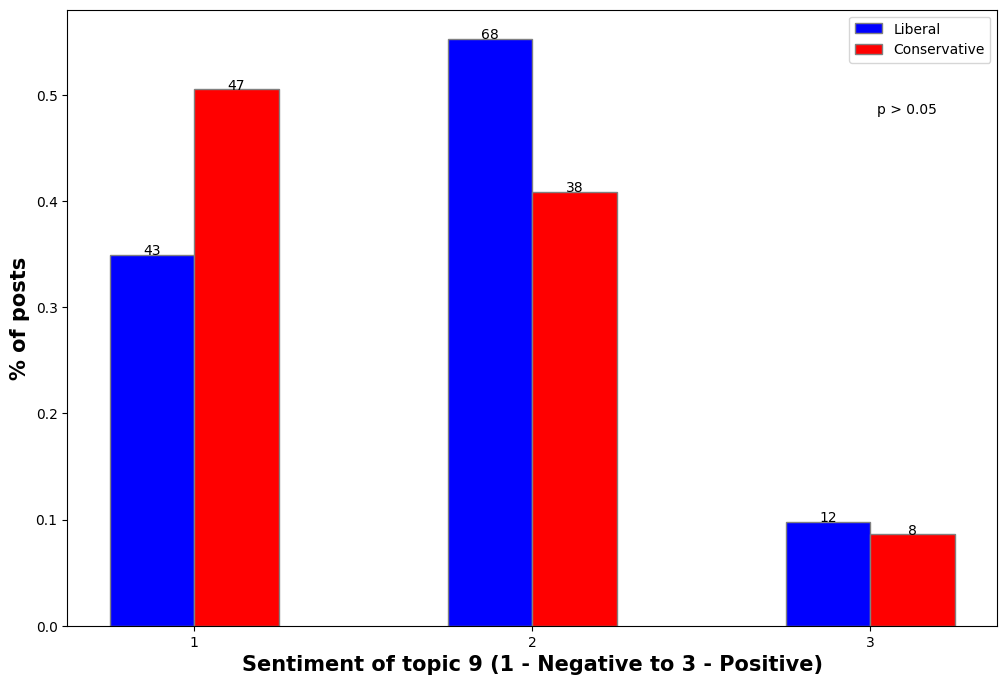

=== Topic 10 ===
{'socialism': [5, 7, 3], 'democrats': [4, 7, 2], 'feminisms': [224, 290, 41], 'alltheleft': [19, 10, 2], 'progressive': [12, 14, 1], 'DemocraticSocialism': [3, 7, 2], 'SocialDemocracy': [2, 5, 1], 'Communist': [3, 5, 0], 'Liberal': [6, 6, 4], 'conservatives': [3, 5, 3], 'Libertarian': [14, 11, 0], 'Capitalism': [2, 3, 0], 'republicans': [3, 5, 0], 'anarchocapitalism': [8, 3, 0]}
After performing chi2 analysis, we find a p-value of 0.315228195760836


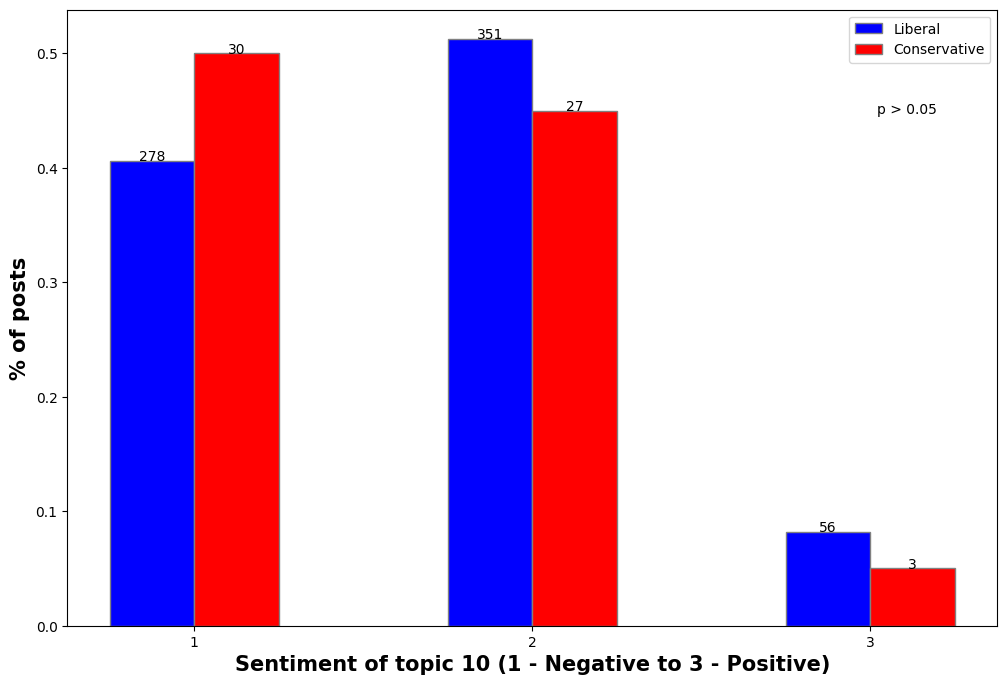

=== Topic 11 ===
{'socialism': [28, 57, 15], 'SocialDemocracy': [13, 41, 7], 'alltheleft': [10, 25, 8], 'DemocraticSocialism': [21, 23, 9], 'Liberal': [1, 2, 1], 'progressive': [6, 17, 5], 'democrats': [1, 3, 1], 'feminisms': [1, 4, 0], 'Communist': [3, 5, 2], 'Capitalism': [14, 17, 2], 'conservatives': [1, 2, 0], 'Libertarian': [3, 9, 0], 'republicans': [1, 0, 0], 'anarchocapitalism': [1, 2, 1]}
After performing chi2 analysis, we find a p-value of 0.08684327828937456


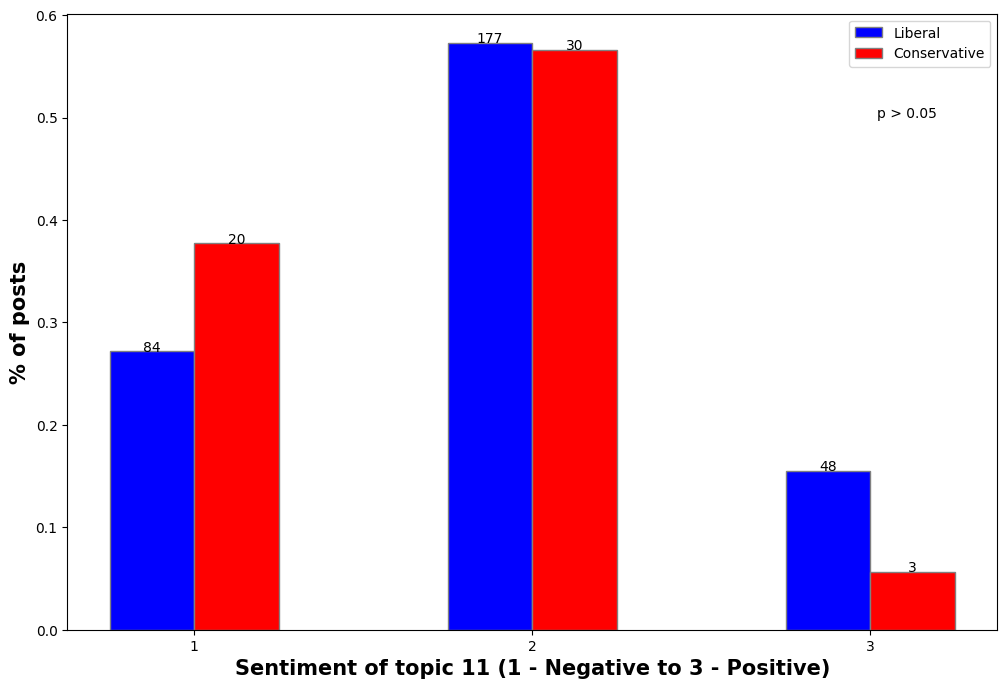

=== Topic 12 ===
{'socialism': [1, 2, 0], 'feminisms': [42, 39, 3], 'alltheleft': [2, 5, 0], 'democrats': [6, 3, 1], 'progressive': [12, 9, 2], 'SocialDemocracy': [1, 0, 0], 'DemocraticSocialism': [2, 0, 0], 'Liberal': [3, 9, 1], 'Communist': [0, 1, 0], 'Libertarian': [8, 6, 0], 'conservatives': [6, 5, 0], 'republicans': [1, 1, 0], 'anarchocapitalism': [0, 1, 0]}
After performing chi2 analysis, we find a p-value of 0.46819684706728304


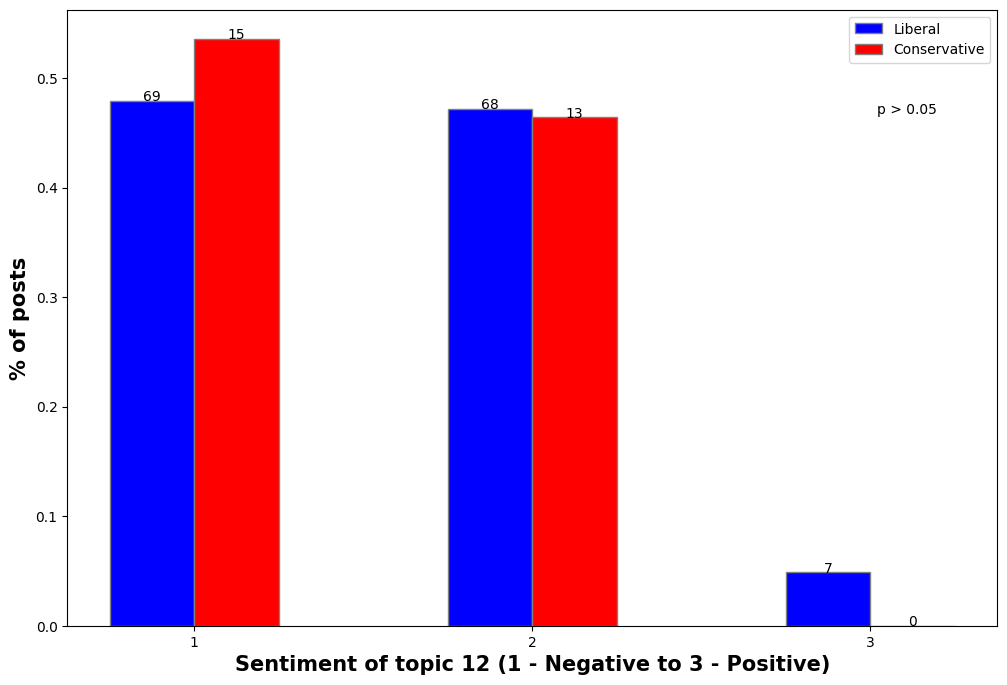

=== Topic 13 ===
{'DemocraticSocialism': [7, 11, 5], 'democrats': [1, 3, 1], 'socialism': [2, 4, 0], 'Liberal': [5, 9, 1], 'alltheleft': [3, 3, 0], 'progressive': [2, 22, 3], 'SocialDemocracy': [3, 9, 0], 'feminisms': [0, 1, 0], 'Communist': [1, 0, 0], 'conservatives': [2, 5, 1], 'republicans': [3, 7, 2], 'Capitalism': [14, 29, 8], 'Libertarian': [6, 7, 1], 'anarchocapitalism': [4, 5, 1]}
After performing chi2 analysis, we find a p-value of 0.4579117710398699


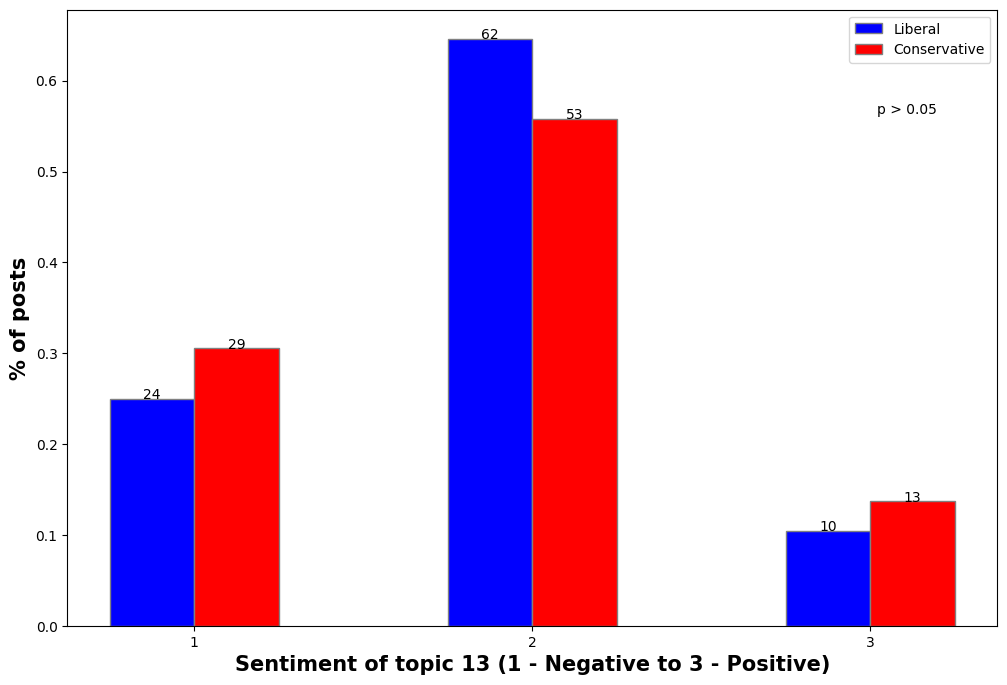

=== Topic 14 ===
{'alltheleft': [38, 27, 2], 'socialism': [36, 38, 2], 'Communist': [11, 10, 1], 'DemocraticSocialism': [11, 11, 1], 'feminisms': [1, 1, 0], 'SocialDemocracy': [9, 10, 0], 'democrats': [2, 2, 0], 'Liberal': [7, 8, 0], 'progressive': [7, 2, 0], 'Libertarian': [5, 7, 2], 'conservatives': [6, 3, 1], 'republicans': [3, 0, 1], 'Capitalism': [1, 7, 0], 'anarchocapitalism': [8, 5, 0]}
After performing chi2 analysis, we find a p-value of 0.14524875745159793


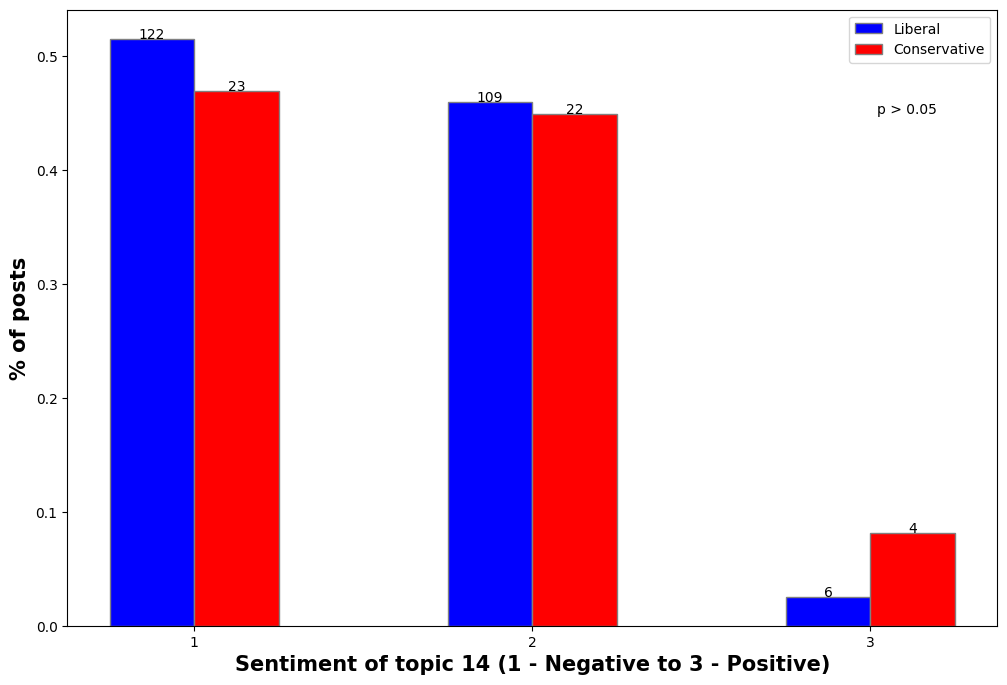

=== Topic 15 ===
{'socialism': [13, 23, 6], 'alltheleft': [1, 11, 4], 'DemocraticSocialism': [0, 8, 2], 'SocialDemocracy': [1, 8, 6], 'Communist': [17, 43, 10], 'democrats': [0, 1, 0], 'feminisms': [1, 3, 1], 'progressive': [0, 1, 1], 'Liberal': [1, 2, 1], 'Libertarian': [2, 3, 1], 'Capitalism': [3, 1, 0]}
After performing chi2 analysis, we find a p-value of 0.09407807152220517


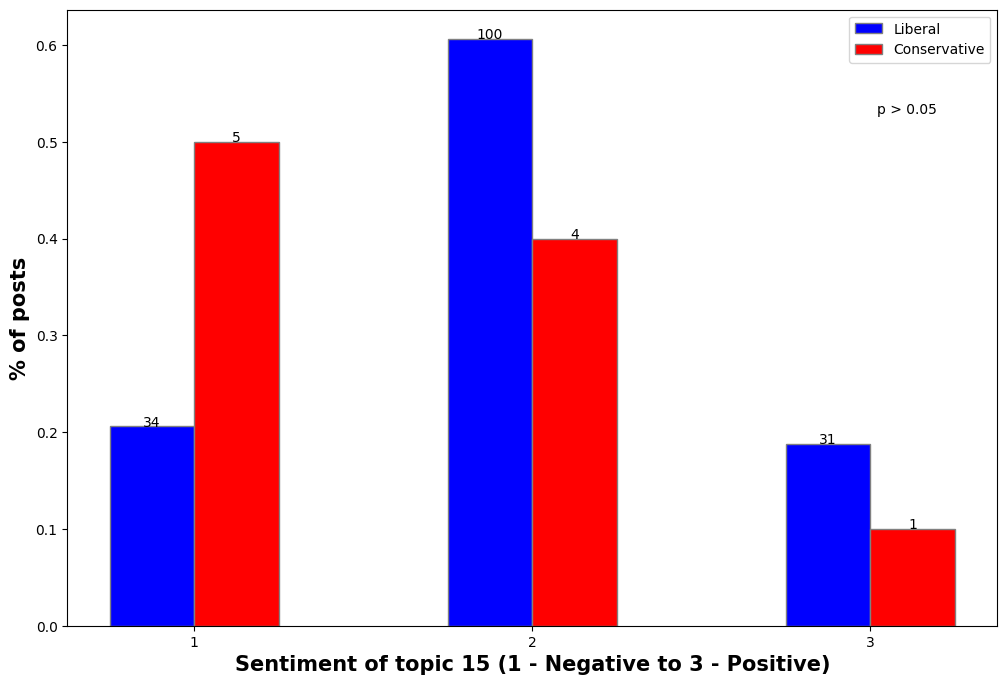

=== Topic 16 ===
{'democrats': [2, 3, 1], 'socialism': [4, 8, 0], 'alltheleft': [3, 6, 0], 'SocialDemocracy': [2, 5, 4], 'Liberal': [4, 3, 0], 'DemocraticSocialism': [3, 2, 1], 'progressive': [8, 4, 1], 'feminisms': [0, 2, 1], 'Communist': [1, 1, 0], 'conservatives': [3, 5, 0], 'republicans': [2, 3, 0], 'Libertarian': [0, 2, 0], 'Capitalism': [6, 3, 0], 'anarchocapitalism': [1, 2, 1]}
After performing chi2 analysis, we find a p-value of 0.46690220954495976


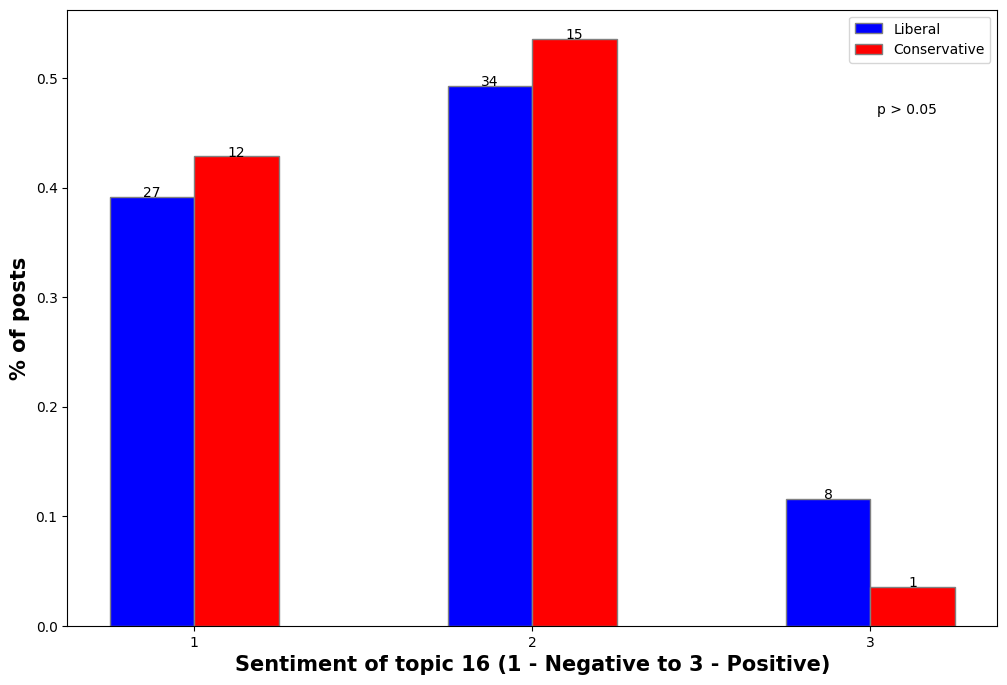

=== Topic 17 ===
{'progressive': [4, 2, 0], 'democrats': [4, 3, 0], 'alltheleft': [0, 1, 0], 'Liberal': [1, 3, 1], 'DemocraticSocialism': [0, 1, 0], 'republicans': [12, 61, 10], 'conservatives': [2, 11, 2], 'Capitalism': [1, 1, 1], 'anarchocapitalism': [0, 3, 0]}
After performing chi2 analysis, we find a p-value of 0.006016156936325838


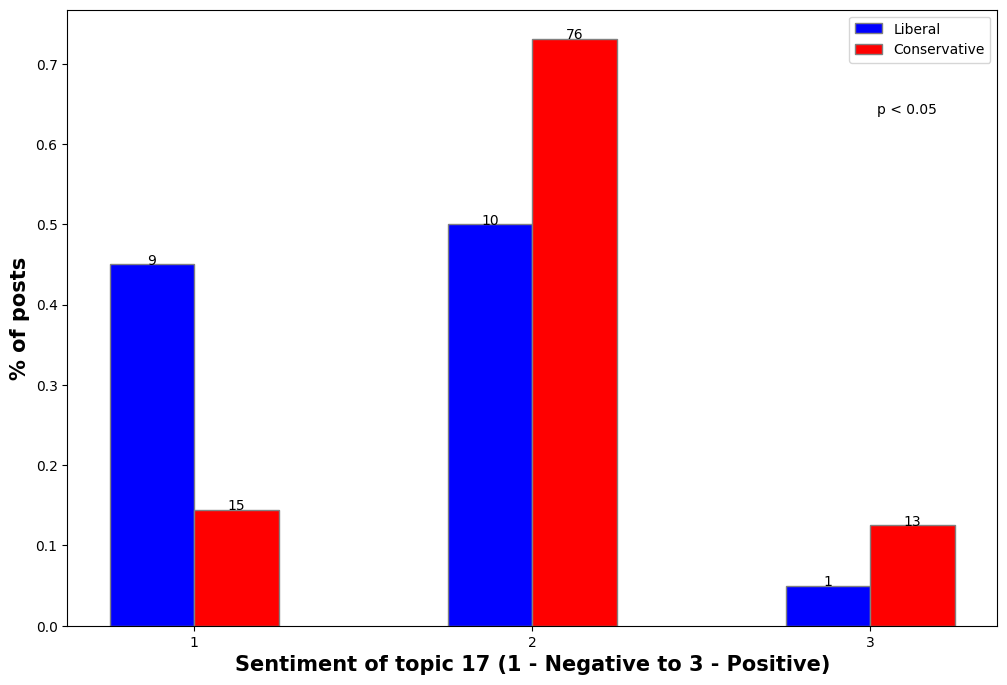

=== Topic 18 ===
{'SocialDemocracy': [1, 4, 1], 'democrats': [0, 2, 0], 'socialism': [4, 3, 0], 'Liberal': [0, 3, 0], 'DemocraticSocialism': [0, 2, 0], 'alltheleft': [1, 1, 2], 'progressive': [0, 0, 1], 'republicans': [2, 0, 0], 'conservatives': [1, 4, 0], 'Libertarian': [2, 4, 1], 'Capitalism': [2, 5, 1], 'anarchocapitalism': [4, 17, 12]}
After performing chi2 analysis, we find a p-value of 0.6366249519703


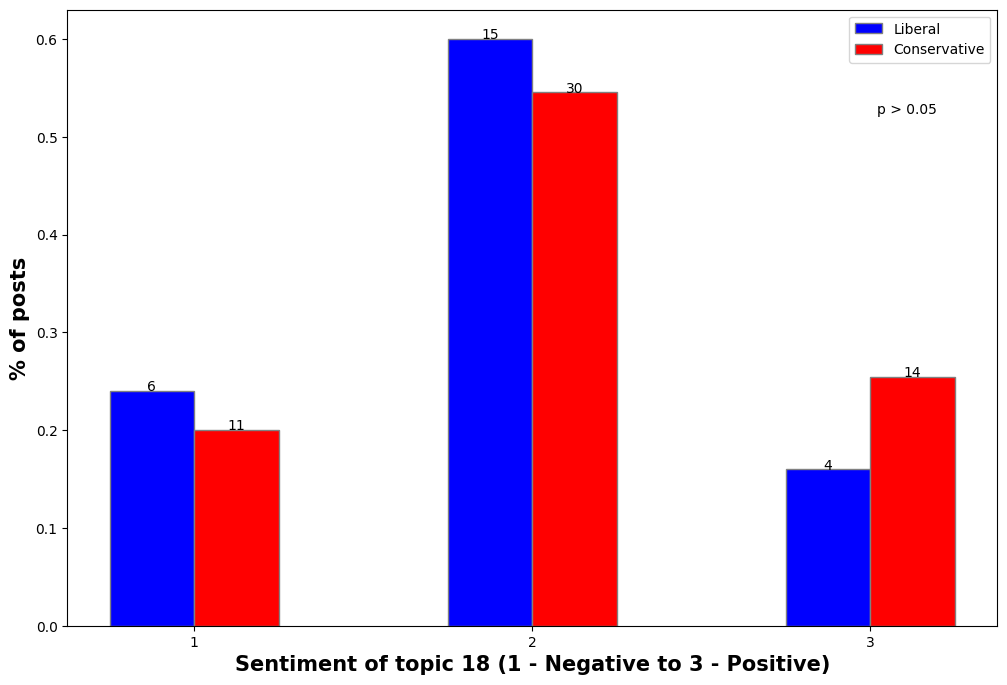

=== Topic 19 ===
{'alltheleft': [1, 4, 1], 'democrats': [5, 4, 0], 'Liberal': [9, 3, 0], 'Communist': [1, 2, 0], 'progressive': [4, 6, 0], 'SocialDemocracy': [1, 1, 0], 'DemocraticSocialism': [3, 0, 0], 'feminisms': [1, 0, 1], 'conservatives': [5, 9, 2], 'republicans': [2, 17, 2], 'Libertarian': [0, 1, 0], 'Capitalism': [2, 3, 0], 'anarchocapitalism': [0, 4, 0]}
After performing chi2 analysis, we find a p-value of 0.0027044572588300207


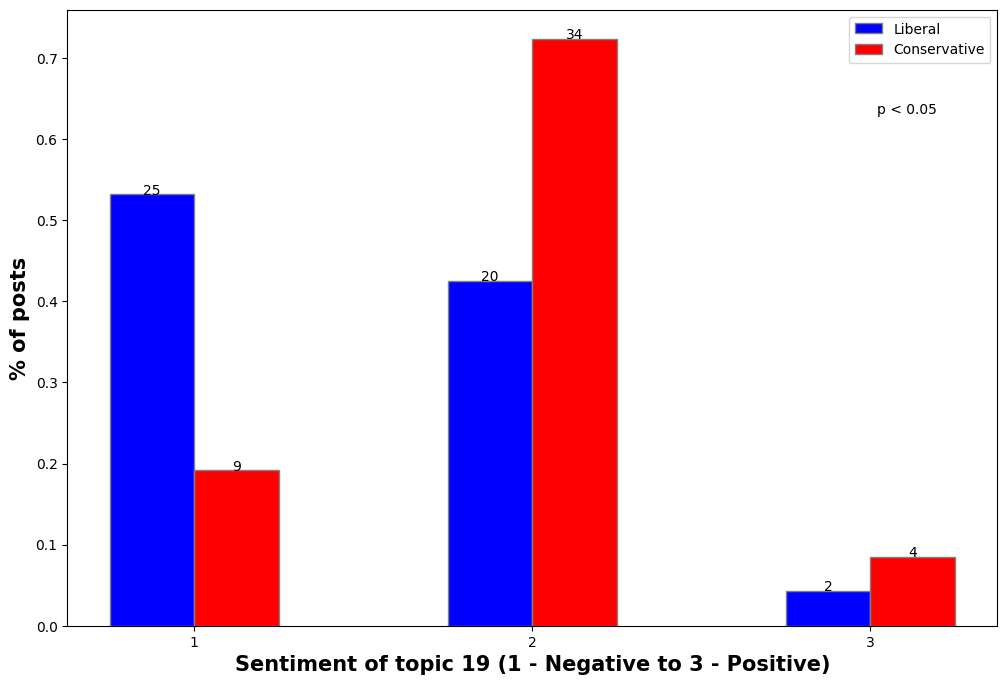

=== Topic 20 ===
{'socialism': [5, 7, 0], 'SocialDemocracy': [3, 9, 0], 'DemocraticSocialism': [4, 4, 1], 'alltheleft': [4, 5, 0], 'democrats': [0, 2, 0], 'progressive': [3, 3, 1], 'Liberal': [2, 1, 0], 'Communist': [0, 1, 0], 'Libertarian': [2, 5, 0], 'republicans': [0, 1, 0], 'Capitalism': [3, 8, 0], 'anarchocapitalism': [1, 10, 0]}
After performing chi2 analysis, we find a p-value of 0.10467926142929956


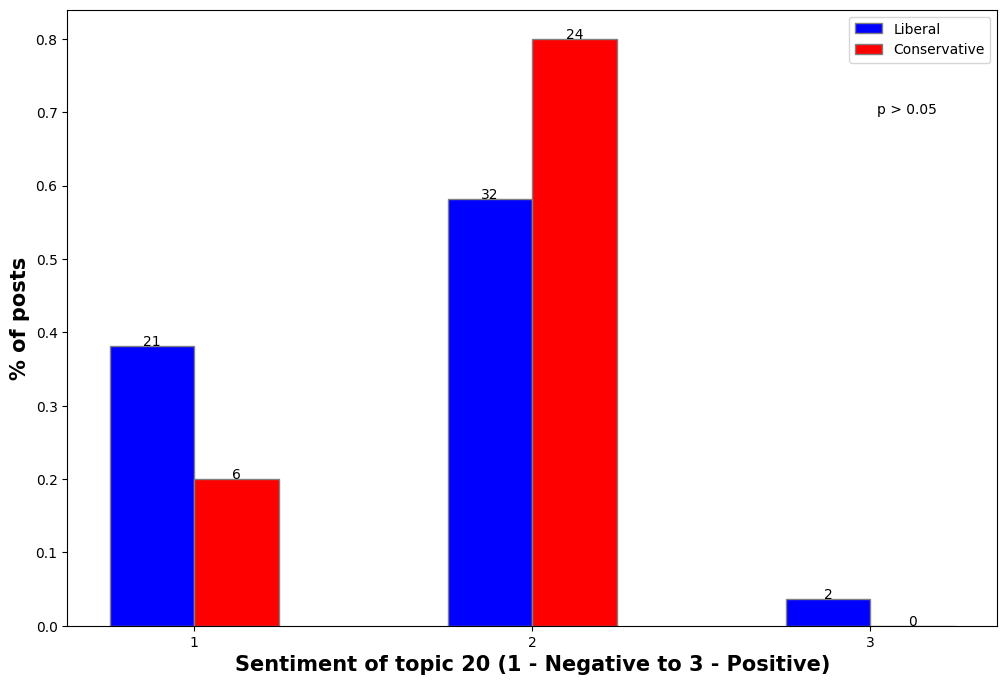

=== Topic 21 ===
{'socialism': [2, 23, 0], 'alltheleft': [1, 16, 4], 'democrats': [2, 1, 0], 'Communist': [1, 27, 3], 'SocialDemocracy': [2, 3, 0], 'DemocraticSocialism': [1, 1, 1], 'feminisms': [0, 0, 1], 'progressive': [0, 1, 0], 'anarchocapitalism': [0, 7, 0], 'Libertarian': [1, 5, 1], 'conservatives': [0, 1, 0], 'Capitalism': [0, 5, 0]}
After performing chi2 analysis, we find a p-value of 0.5769498103804868


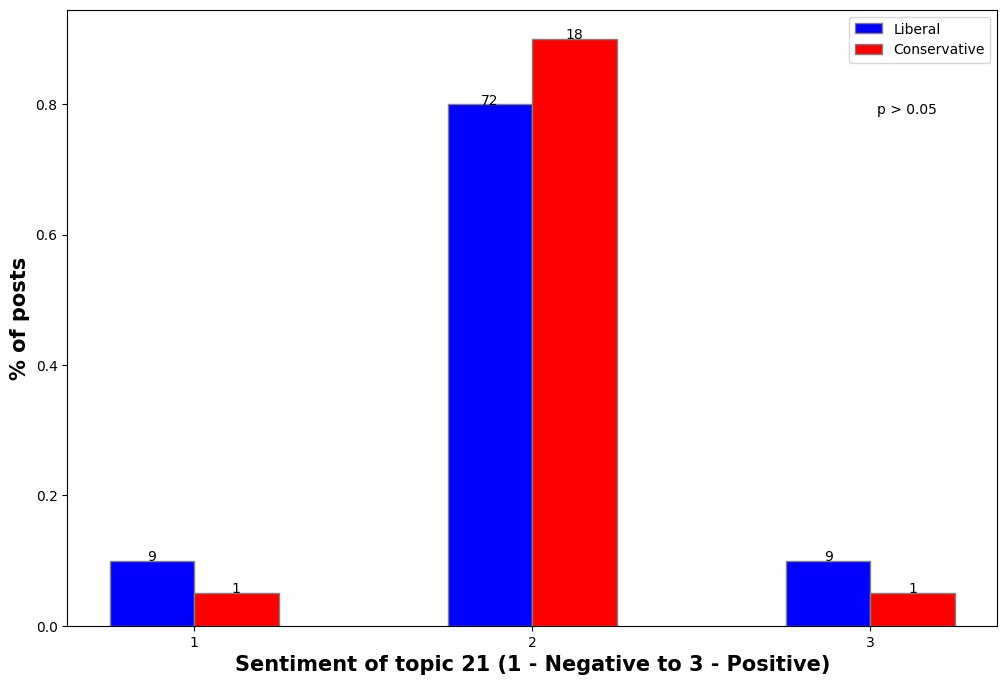

=== Topic 22 ===
{'DemocraticSocialism': [7, 6, 2], 'Liberal': [1, 1, 0], 'alltheleft': [1, 4, 1], 'SocialDemocracy': [6, 4, 0], 'socialism': [1, 1, 1], 'democrats': [0, 4, 0], 'progressive': [3, 6, 0], 'Communist': [0, 1, 0], 'conservatives': [1, 0, 0], 'Libertarian': [2, 1, 0], 'Capitalism': [7, 7, 0], 'republicans': [1, 1, 0], 'anarchocapitalism': [2, 0, 1]}
After performing chi2 analysis, we find a p-value of 0.32531214589011836


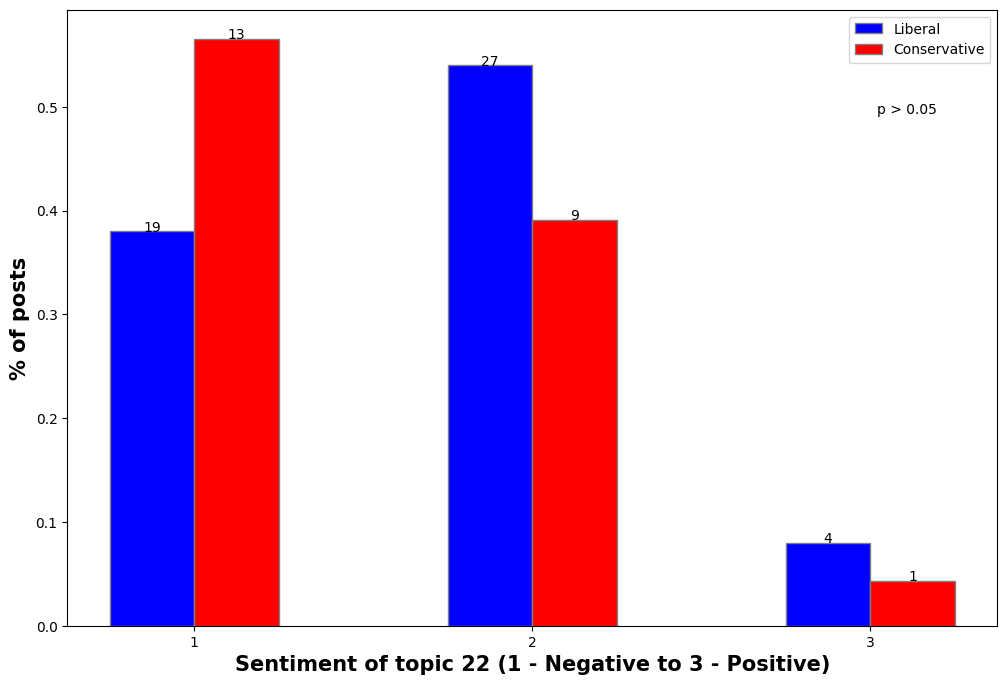

=== Topic 23 ===
{'democrats': [2, 3, 0], 'socialism': [1, 1, 1], 'progressive': [3, 1, 0], 'alltheleft': [2, 0, 1], 'DemocraticSocialism': [2, 0, 0], 'Liberal': [0, 1, 0], 'feminisms': [0, 1, 0], 'conservatives': [2, 0, 1], 'Libertarian': [3, 2, 0], 'republicans': [0, 1, 0], 'Capitalism': [3, 3, 0], 'anarchocapitalism': [0, 0, 1]}
After performing chi2 analysis, we find a p-value of 0.9790655744234161


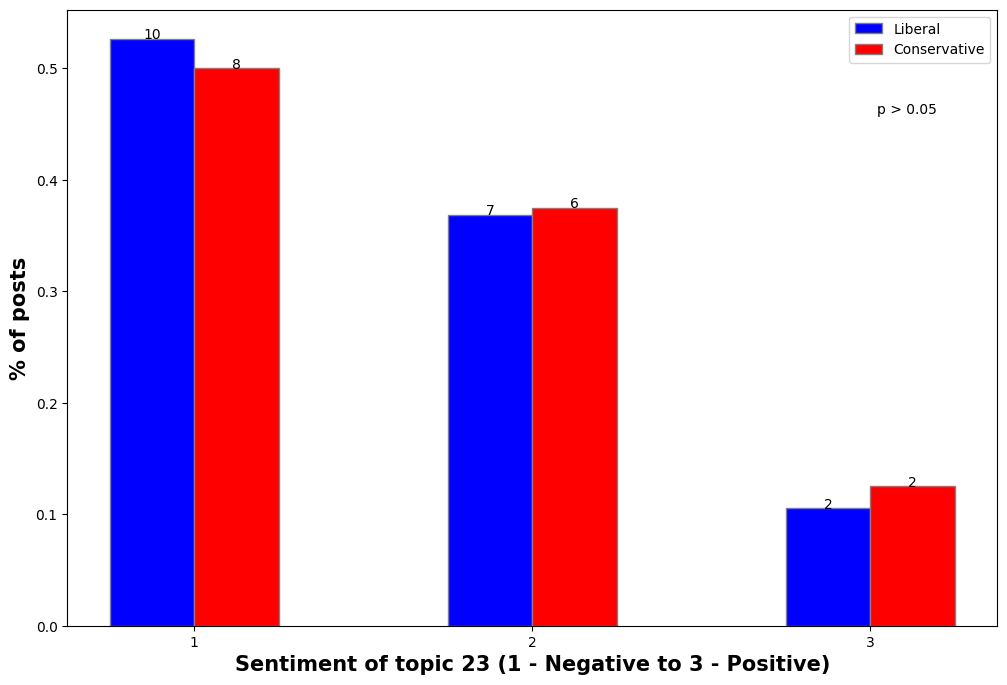

=== Topic 24 ===
{'socialism': [2, 0, 0], 'SocialDemocracy': [0, 1, 0], 'feminisms': [1, 0, 0], 'Communist': [14, 20, 2], 'Libertarian': [0, 1, 0], 'conservatives': [1, 0, 0]}
After performing chi2 analysis, we find a p-value of 0.9383461542822089


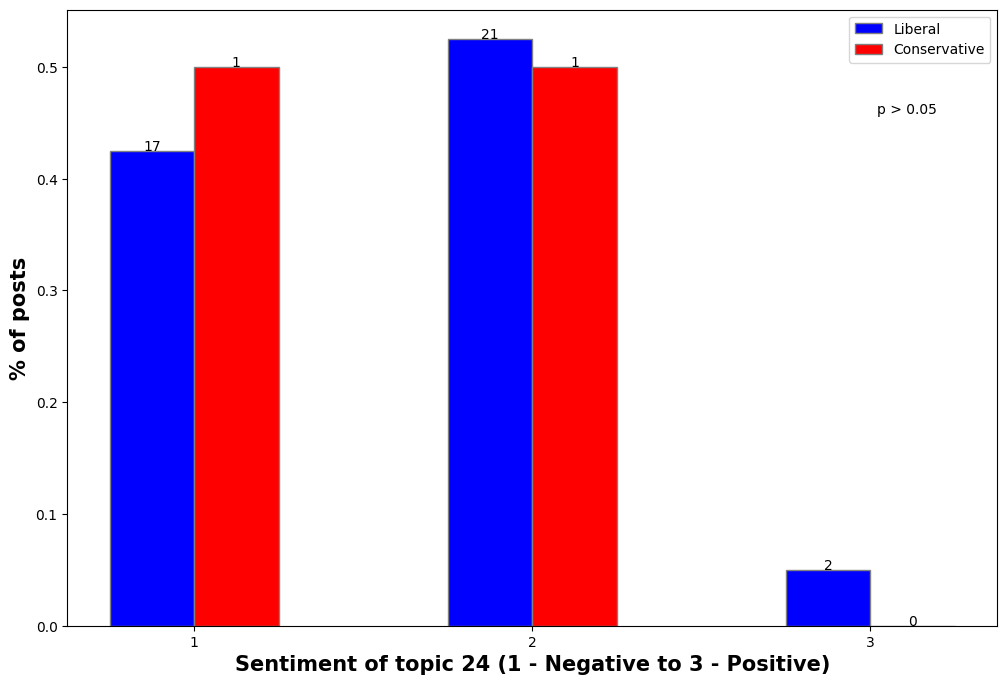

=== Topic 25 ===
{'democrats': [2, 10, 1], 'progressive': [2, 3, 1], 'alltheleft': [0, 1, 0], 'Liberal': [1, 2, 0], 'feminisms': [0, 1, 0], 'Libertarian': [1, 2, 1], 'Capitalism': [0, 1, 0], 'anarchocapitalism': [0, 1, 0]}
After performing chi2 analysis, we find a p-value of 0.8241090785502163


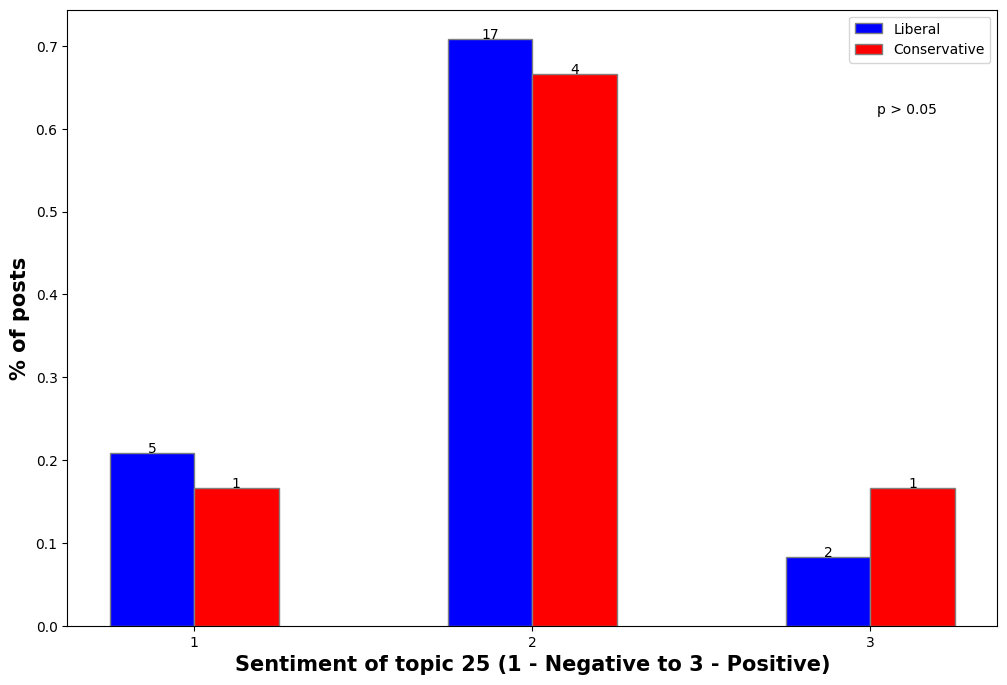

=== Topic 26 ===
{'alltheleft': [1, 7, 2], 'DemocraticSocialism': [0, 5, 0], 'democrats': [0, 1, 0], 'feminisms': [0, 1, 0], 'conservatives': [1, 2, 0], 'Libertarian': [1, 0, 1], 'republicans': [1, 3, 1], 'Capitalism': [0, 1, 0]}
After performing chi2 analysis, we find a p-value of 0.21712702516648455


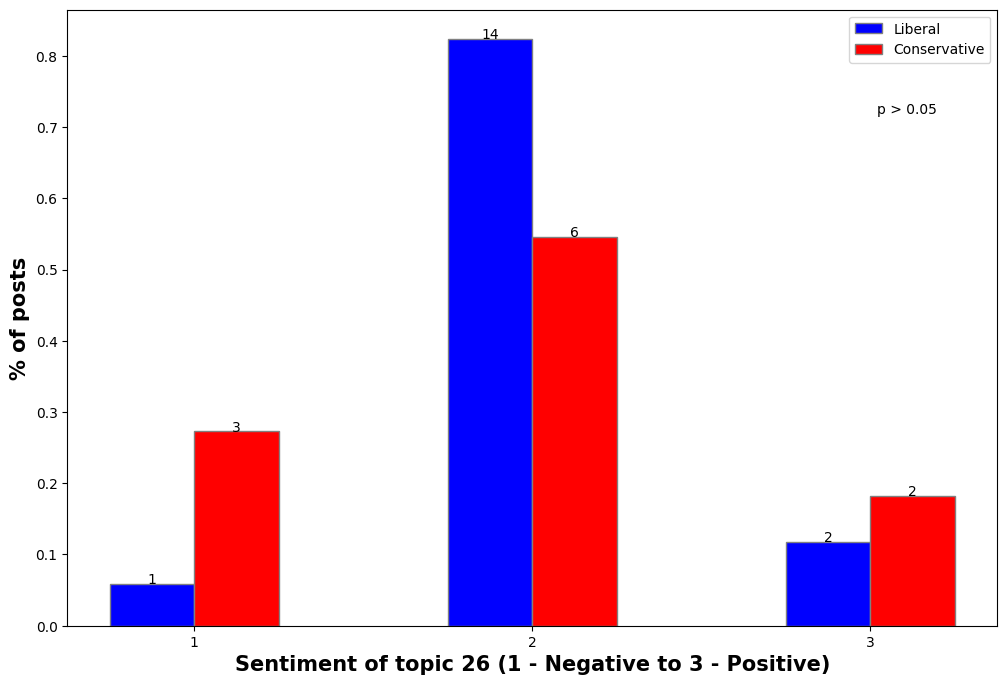

=== Topic 27 ===
{'DemocraticSocialism': [0, 1, 0], 'anarchocapitalism': [5, 13, 2]}
After performing chi2 analysis, we find a p-value of 0.7691263643685705


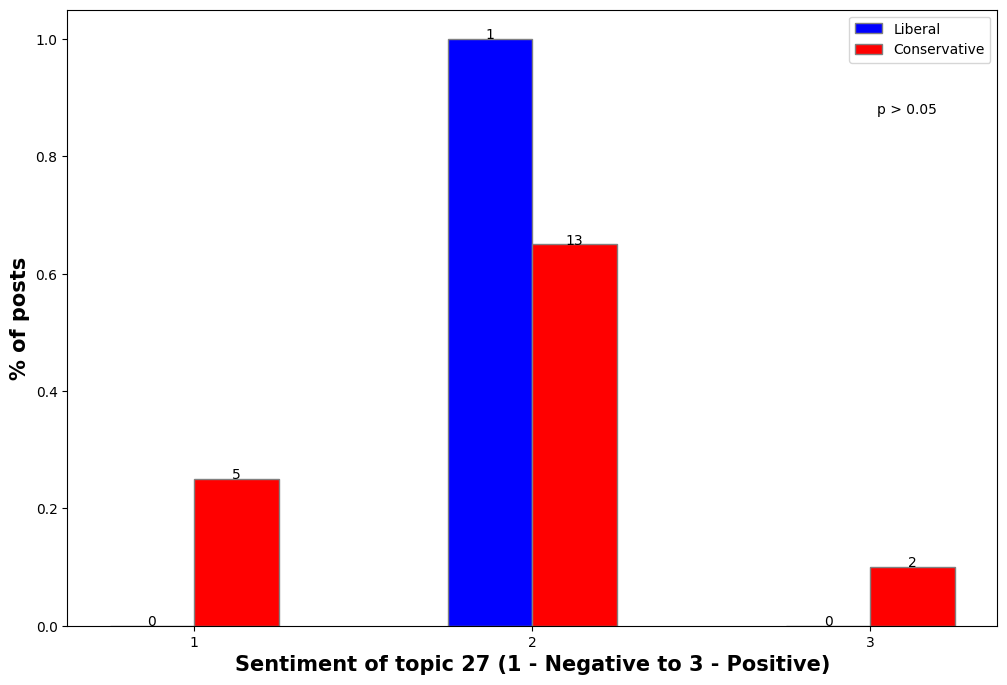

=== Topic 28 ===
{'democrats': [3, 0, 0], 'Libertarian': [3, 1, 0], 'conservatives': [1, 0, 0], 'republicans': [1, 3, 0]}


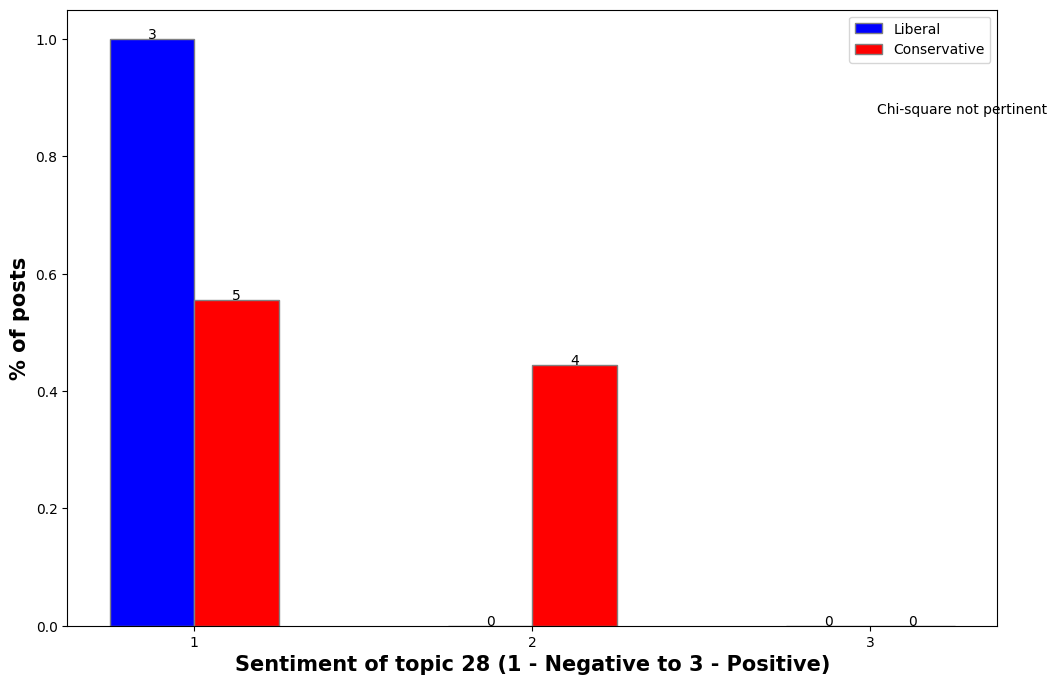

In [ ]:
list_of_topics = set(df_sentiment_topics["most_common_topic"].to_list())
for topic in list_of_topics:
    analyse_topics(topic, normalize=True)

In [ ]:
topic_list = np.zeros(len(set(df_topics["most_common_topic"].to_list())))
for i in range(len(df_topics)):
    post = df_topics.iloc[i]
    topic_list[post["most_common_topic"]] += 1
print(topic_list)
print(len(topic_list))

[2305.  907.  817. 1216.  332.  309.  342.  486.  307.  216.  745.  362.
  172.  191.  286.  175.   97.  124.   80.   94.   85.  110.   73.   35.
   42.   30.   28.   21.   12.]
29


# Sentiment statistics

In [ ]:
# Sentiments per subreddit (not-weighted)
list_of_subreddits = set(df["Subreddit"].to_list())
distributions = []
subreddit_averages = {}
for subreddit in list_of_subreddits:
    num_sub_posts = df.groupby("Subreddit").size()[subreddit]
    sub_distribution = df[df["Subreddit"] == subreddit].groupby(by="Sentiment").size().to_list()
    distributions.append(sub_distribution)
    subreddit_averages[subreddit] = sum((rating + 1) * count for rating, count in enumerate(sub_distribution)) / num_sub_posts

print(f"After performing chi2 analysis, we find a p-value of {chisquare_analysis(distributions)}")

# Print the subreddits per average of sentiments
subreddit_averages = dict(sorted(subreddit_averages.items(), reverse=True, key=lambda item: item[1]))
print(subreddit_averages)

After performing chi2 analysis, we find a p-value of 2.947767209074292e-50
{'SocialDemocracy': np.float64(1.9291338582677164), 'Communist': np.float64(1.8574712643678162), 'anarchocapitalism': np.float64(1.8139059304703475), 'socialism': np.float64(1.7903645833333333), 'Capitalism': np.float64(1.7808041504539558), 'DemocraticSocialism': np.float64(1.773972602739726), 'democrats': np.float64(1.7510668563300142), 'alltheleft': np.float64(1.729899497487437), 'republicans': np.float64(1.7115135834411384), 'conservatives': np.float64(1.6713554987212276), 'Libertarian': np.float64(1.6569920844327177), 'feminisms': np.float64(1.6554054054054055), 'progressive': np.float64(1.649673202614379), 'Liberal': np.float64(1.562585969738652)}


In [ ]:
# Sentiments per subreddit (weighted)
list_of_subreddits = set(df["Subreddit"].to_list())

distributions = []
subreddit_averages = {}

for subreddit in list_of_subreddits:
    sentiment_sub_weighted = [0,0,0]

    subreddit_posts = df[df["Subreddit"] == subreddit]
    for i in range(len(subreddit_posts)):
        post = subreddit_posts.iloc[i]
        sentiment_sub_weighted[post["Sentiment"]-1] += post["Score"]

    distributions.append(sentiment_sub_weighted)
    subreddit_averages[subreddit] = sum((rating + 1) * count for rating, count in enumerate(sentiment_sub_weighted)) / sum(sentiment_sub_weighted)

print(f"After performing chi2 analysis, we find a p-value of {chisquare_analysis(distributions)}")

# Print the subreddits per average of sentiments
subreddit_averages = dict(sorted(subreddit_averages.items(), reverse=True, key=lambda item: item[1]))
print(subreddit_averages)

After performing chi2 analysis, we find a p-value of 0.0
{'SocialDemocracy': np.float64(1.9409900392393602), 'Communist': np.float64(1.8793800539083558), 'alltheleft': np.float64(1.7997991694465245), 'Capitalism': np.float64(1.7927934206858098), 'anarchocapitalism': np.float64(1.7435787671232876), 'socialism': np.float64(1.7392950681952954), 'conservatives': np.float64(1.7296555509811995), 'republicans': np.float64(1.6949090240764566), 'democrats': np.float64(1.6928323912761174), 'DemocraticSocialism': np.float64(1.6318303298943413), 'progressive': np.float64(1.5932667936015135), 'feminisms': np.float64(1.5347123382990164), 'Liberal': np.float64(1.4654261485971711), 'Libertarian': np.float64(1.3633364027010435)}


In [ ]:
# Sentiments per topic (not-weighted)
list_of_topics = set(df_sentiment_topics["most_common_topic"].to_list())

distributions = []
topic_averages = {}
for topic in list_of_topics:
    topic_sub_weighted = [0,0,0]

    topic_posts = df_sentiment_topics[df_sentiment_topics["most_common_topic"] == topic]
    for i in range(len(topic_posts)):
        post = topic_posts.iloc[i]
        topic_sub_weighted[post["Sentiment"]-1] += 1

    distributions.append(topic_sub_weighted)
    topic_averages[topic] = sum((rating + 1) * count for rating, count in enumerate(topic_sub_weighted)) / sum(topic_sub_weighted)

print(f"After performing chi2 analysis, we find a p-value of {chisquare_analysis(distributions)}")

# Print the subreddits per average of sentiments
topic_averages = dict(sorted(topic_averages.items(), reverse=True, key=lambda item: item[1]))
print(topic_averages)

After performing chi2 analysis, we find a p-value of 5.591980295512359e-109
{4: 2.075301204819277, 18: 2.0125, 21: 2.0, 26: 2.0, 15: 1.96, 17: 1.9193548387096775, 25: 1.9, 0: 1.8850325379609545, 27: 1.8571428571428572, 11: 1.8535911602209945, 13: 1.8429319371727748, 20: 1.7058823529411764, 19: 1.702127659574468, 16: 1.690721649484536, 9: 1.6759259259259258, 10: 1.665771812080537, 1: 1.6582138919514884, 8: 1.6579804560260587, 2: 1.631578947368421, 3: 1.631578947368421, 22: 1.63013698630137, 24: 1.619047619047619, 7: 1.6069958847736625, 23: 1.6, 5: 1.5533980582524272, 12: 1.552325581395349, 6: 1.543859649122807, 14: 1.527972027972028, 28: 1.3333333333333333}


In [ ]:
# Sentiments per topic (weighted)
list_of_topics = set(df_sentiment_topics["most_common_topic"].to_list())

distributions = []
topic_averages = {}
for topic in list_of_topics:
    topic_sub_weighted = [0,0,0]

    topic_posts = df_sentiment_topics[df_sentiment_topics["most_common_topic"] == topic]
    for i in range(len(topic_posts)):
        post = topic_posts.iloc[i]
        topic_sub_weighted[post["Sentiment"]-1] += post["Score"]

    distributions.append(topic_sub_weighted)
    topic_averages[topic] = sum((rating + 1) * count for rating, count in enumerate(topic_sub_weighted)) / sum(topic_sub_weighted)

print(f"After performing chi2 analysis, we find a p-value of {chisquare_analysis(distributions)}")

# Print the subreddits per average of sentiments
topic_averages = dict(sorted(topic_averages.items(), reverse=True, key=lambda item: item[1]))
print(topic_averages)

NameError: name 'df_sentiment_topics' is not defined